In [29]:
import os
import sys
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'src'))

from pathlib import Path
import cv2
import pickle
import numpy as np
import matplotlib.pyplot as plt
import math
import json
from datetime import date
plt.rcParams["figure.figsize"] = (24,18)

from ultralytics import YOLO

In [30]:
model = YOLO("yolov8n.pt")

In [31]:
data_path = os.path.join(os.path.dirname(os.getcwd()), 'data')
vid_name =  'Ars-MC 1st half'

True


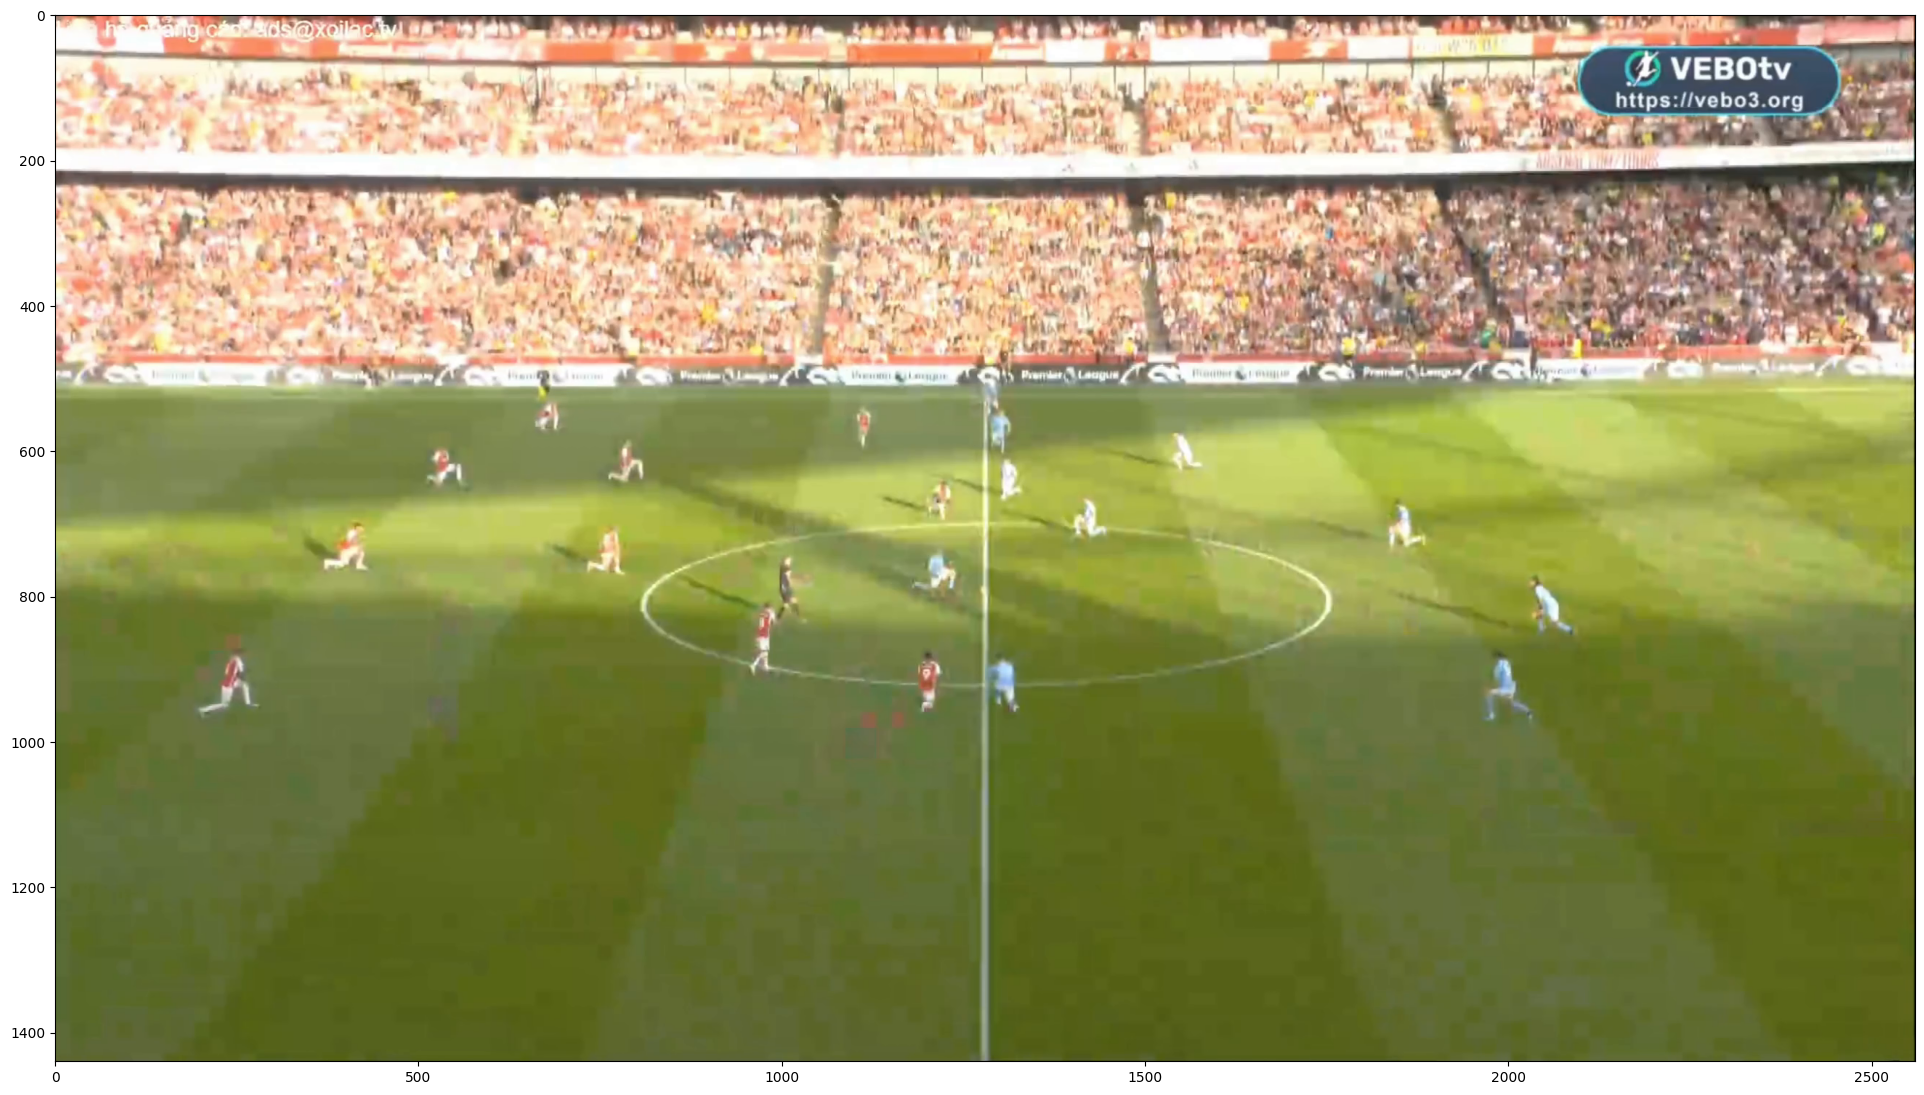

In [32]:
images_path = os.path.join(data_path, 'images' + '/' + vid_name)
print(os.path.exists(images_path))
images_path
image_path = os.path.join(images_path, '000000000140.png')

rgb_image = cv2.imread(image_path, cv2.COLOR_BGR2RGB)

plt.figure()
plt.imshow(rgb_image[:,:,::-1])


0: 384x640 15 persons, 75.5ms
Speed: 89.0ms preprocess, 75.5ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)


0.0
Object type: tensor([0.])
[953, 810, 992, 907]
0.0
Object type: tensor([0.])
[1184, 878, 1223, 961]
0.0
Object type: tensor([0.])
[224, 864, 273, 955]
0.0
Object type: tensor([0.])
[1404, 661, 1439, 722]
0.0
Object type: tensor([0.])
[1831, 669, 1866, 737]
0.0
Object type: tensor([0.])
[1287, 884, 1329, 962]
0.0
Object type: tensor([0.])
[1970, 882, 2015, 949]
0.0
Object type: tensor([0.])
[996, 749, 1027, 835]
0.0
Object type: tensor([0.])
[203, 858, 276, 959]
0.0
Object type: tensor([0.])
[764, 586, 809, 652]
0.0
Object type: tensor([0.])
[1195, 740, 1244, 802]
0.0
Object type: tensor([0.])
[514, 590, 563, 656]
0.0
Object type: tensor([0.])
[738, 706, 782, 767]
0.0
Object type: tensor([0.])
[1100, 539, 1126, 600]
0.0
Object type: tensor([0.])
[1964, 881, 2031, 976]


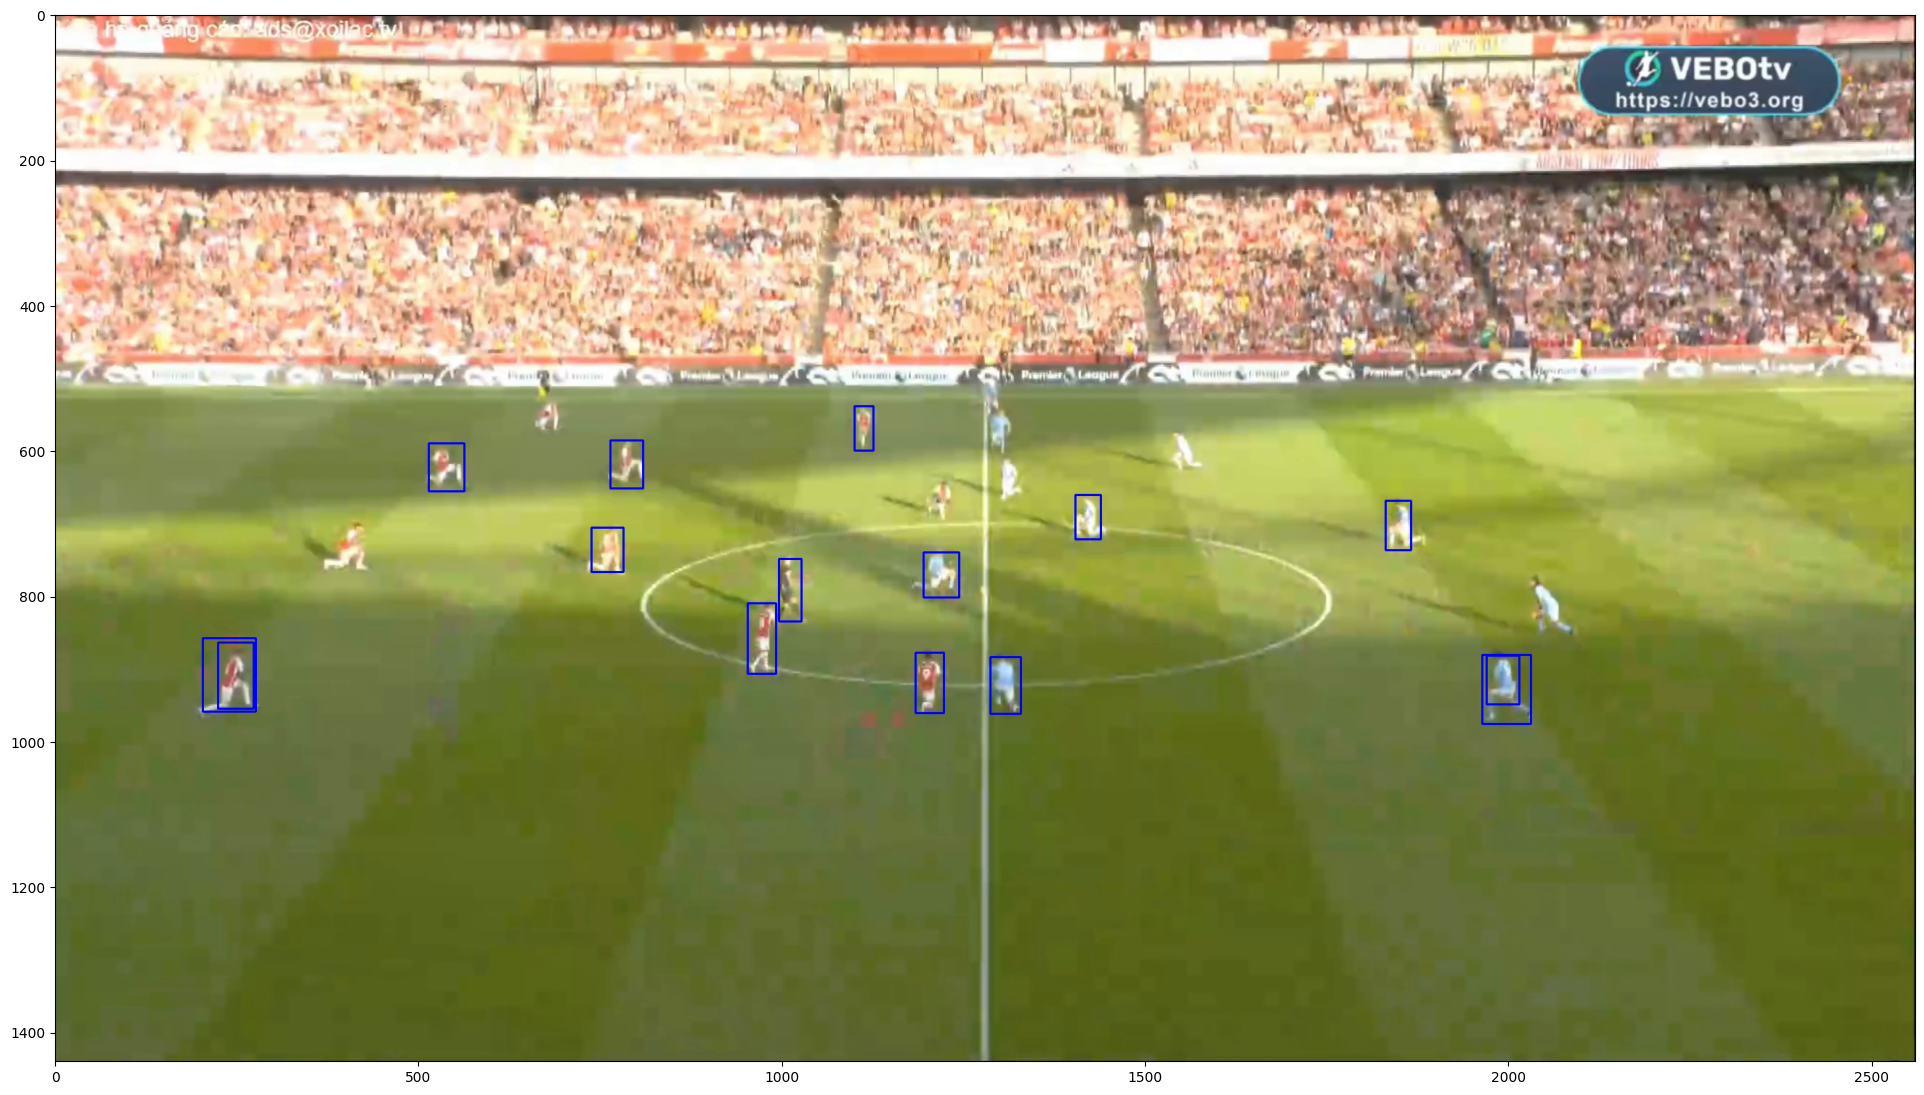

In [33]:
results = model.predict(rgb_image)

for result in results:
    boxes = result.boxes
    for box in boxes:
        coord = box.xyxy.cpu().detach().int().tolist()[0]
        class_id = box.cls[0].item()
        print(class_id)
        print("Object type:", box.cls)
        
        print(coord)
        (startX, startY, endX, endY) = coord
        cv2.rectangle(rgb_image, (startX, startY), (endX, endY),
    				(255, 0, 0), 2)
        
        
        
plt.figure()
plt.imshow(rgb_image[:,:,::-1])


In [34]:
sequence_of_frames = list(range(140, 727))
dest_path = os.path.join(data_path, 'annotated_frames' + '/' + vid_name)
if not os.path.exists(dest_path):
    os.mkdir(dest_path)

coco_dict ={}
frame_id = 1
obj_id = 1
categories_dict = [{"id" : 1, "name" : "person", "supercategory" : None},
                   {"id" : 2, "name" : "ball", "supercategory" : None}]

creation_date = date.today()
year = creation_date.year
coco_info = {
    'contributor': 'Khoa Nguyen, Huy Nguyen',
    'description': vid_name,
    'url': '',
    'version': 0,
    'date_created': str(creation_date),
    'year': year,
}

images = []
annotations = []

for frame_no in sequence_of_frames:
    frame_number = str(frame_no)
    while len(frame_number) < len("000000000526"):
        frame_number = "0" + frame_number
    frame_number = frame_number + ".png"
    frame = os.path.join(images_path, frame_number)
    # Get image shape for COCO dataset:
    h, w, _ = cv2.imread(frame, cv2.IMREAD_UNCHANGED).shape

    # Set image metadata for COCO dataset:
    metadata = {"height" : h,
                "width" : w,
                "id" : frame_id,
                "file_name": os.path.basename(frame)}
    images.append(metadata)

    # Run YOLOv8 inference on the frame
    results = model(frame, classes=[0, 32])

    # Visualize the results on the frame
    annotated_frame = results[0].plot()

    # Display the annotated frame
    cv2.imwrite(os.path.join(dest_path, frame_number), annotated_frame)
    
    # Write information to coco dataset:
    boxes = results[0].boxes
    for box in boxes:
        coord = box.xywh.cpu().detach().int().tolist()[0]
        class_id = box.cls[0].item()
        bbox = {"id" : obj_id,
                "image_id" : frame_id,
                "category_id" : 1 if class_id == 0.0 else 2,
                "segmentation" : [],
                "bbox" : coord,
                "area" : coord[2] * coord[3],
                "iscrowd" : 0}
        
        annotations.append(bbox)
        obj_id += 1
    frame_id += 1


coco_dict["info"] = coco_info
coco_dict["license"] = {'name': vid_name,
                        'id': '',
                        'url': ''}
coco_dict["categories"] = categories_dict
coco_dict["images"] = images
coco_dict["annotations"] = annotations

with open(os.path.join(dest_path, vid_name+'.json'), 'w') as coco:
    json.dump(coco_dict, coco)



image 1/1 /media/khoa-ys/Personal/Projects/Football Analysis/Football-analysis/data/images/Ars-MC 1st half/000000000140.png: 384x640 15 persons, 48.5ms
Speed: 2.4ms preprocess, 48.5ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)


AttributeError: 'list' object has no attribute 'boxes'

In [ ]:
ref_image = cv2.imread(os.path.join(dest_path, os.listdir(dest_path)[0]), cv2.IMREAD_UNCHANGED)
h, w, _ = ref_image.shape
video= cv2.VideoWriter(os.path.join(dest_path, vid_name+'.mp4'), cv2.VideoWriter_fourcc(*'mp4v'), 3, (w,h))
for image_name in os.listdir(dest_path):
    frame = cv2.imread(os.path.join(dest_path, image_name), cv2.IMREAD_UNCHANGED)
    video.write(frame)
video.release()